# S&P 500 Long-Term Return Analysis (1871–2026)
## Do Stocks Always Win in the Long Run? A Data-Driven Guide for Retail Investors

**Author:** [Your Name / Student ID]  
**Date:** April 2026  
**Module:** ACC102 – Python Data Product (Mini Assignment)  
**Track:** Track 2 – GitHub Data Analysis Project

---

### Project Overview

"Stocks always go up in the long run" is one of the most common pieces of investment advice. But is it true? And if so, *how long* is "the long run"? This notebook uses over 150 years of S&P 500 data to investigate the historical relationship between holding period, valuation, inflation, and investment returns.

**Analytical Problem:**  
*For a retail investor deciding between stocks and bonds, what does 150 years of S&P 500 history tell us about the probability of positive real (inflation-adjusted) returns over different holding periods, and how does the market's starting valuation (PE10 ratio) affect expected returns?*

**Target User:**  
Retail investors and personal finance enthusiasts who want evidence-based guidance on long-term investment strategy.

### Data Source

| Item | Detail |
|------|--------|
| **Dataset** | Robert Shiller's S&P 500 Historical Data |
| **Original Source** | [Robert J. Shiller](http://www.econ.yale.edu/~shiller/data.htm), Nobel Laureate in Economics (2013) |
| **Repository** | [github.com/datasets/s-and-p-500](https://github.com/datasets/s-and-p-500) (Open Data, PDDL license) |
| **Format** | CSV, monthly frequency |
| **Coverage** | January 1871 – April 2026 (155 years) |
| **Variables** | S&P 500 price, dividends, earnings, CPI, long-term interest rate, real price, PE10 (CAPE ratio) |
| **Date Accessed** | April 2026 via `git clone` |

This is one of the most widely cited financial datasets in academic research, used in Shiller's book *Irrational Exuberance* and in hundreds of peer-reviewed studies.


## 1. Setup and Data Loading

We clone the dataset directly from GitHub and load it into a pandas DataFrame. This ensures full reproducibility — anyone can run this notebook and obtain the same data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import subprocess
import os
import warnings
warnings.filterwarnings('ignore')

# Visual style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 13
})

print("Libraries loaded successfully.")
print(f"pandas {pd.__version__}, numpy {np.__version__}")


Libraries loaded successfully.
pandas 3.0.1, numpy 2.4.3


In [2]:
# Clone the dataset from GitHub (open data repository)
data_dir = 'data'
repo_url = 'https://github.com/datasets/s-and-p-500.git'

if not os.path.exists(os.path.join(data_dir, 'data.csv')):
    print("Cloning dataset from GitHub...")
    subprocess.run(['git', 'clone', '--depth', '1', repo_url, 'sp500_repo'], 
                   capture_output=True, text=True)
    os.makedirs(data_dir, exist_ok=True)
    subprocess.run(['cp', 'sp500_repo/data/data.csv', os.path.join(data_dir, 'data.csv')],
                   capture_output=True)
    print("Dataset cloned and copied to data/data.csv")
else:
    print("Dataset already exists locally.")

# Load the data
df = pd.read_csv(os.path.join(data_dir, 'data.csv'), parse_dates=['Date'])
print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")
print(f"Columns: {list(df.columns)}")
df.head()


Cloning dataset from GitHub...


Dataset cloned and copied to data/data.csv

Dataset shape: (1864, 10)
Date range: 1871-01 to 2026-04
Columns: ['Date', 'SP500', 'Dividend', 'Earnings', 'Consumer Price Index', 'Long Interest Rate', 'Real Price', 'Real Dividend', 'Real Earnings', 'PE10']


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,0.0
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,0.0
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,0.0
3,1871-04-01,4.74,0.26,0.4,12.56,5.33,115.54,6.34,9.75,0.0
4,1871-05-01,4.86,0.26,0.4,12.27,5.33,121.22,6.48,9.98,0.0


## 2. Data Cleaning and Preparation

The raw dataset requires several cleaning steps before analysis:
1. Remove rows with missing or zero values in key columns
2. Compute additional metrics (monthly returns, real total returns including dividends)
3. Validate data integrity


In [3]:
# Inspect data quality
print("=== Data Quality Check ===\n")
print("Missing values:")
print(df.isnull().sum())
print(f"\nZero values in key columns:")
for col in ['SP500', 'Consumer Price Index', 'Real Price']:
    print(f"  {col}: {(df[col] == 0).sum()} zeros")


=== Data Quality Check ===

Missing values:
Date                    0
SP500                   0
Dividend                0
Earnings                0
Consumer Price Index    0
Long Interest Rate      0
Real Price              0
Real Dividend           0
Real Earnings           0
PE10                    0
dtype: int64

Zero values in key columns:
  SP500: 0 zeros
  Consumer Price Index: 31 zeros
  Real Price: 31 zeros


In [4]:
# Clean the data
# 1. Drop rows where SP500 price is 0 or NaN
df_clean = df[df['SP500'] > 0].copy()

# 2. Drop rows where CPI is 0 (needed for real return calculations)
df_clean = df_clean[df_clean['Consumer Price Index'] > 0].copy()

# 3. Drop rows where Real Price is 0 or missing (recent months may lack this)
df_clean = df_clean[df_clean['Real Price'] > 0].copy()

# 4. Filter out PE10 == 0 rows for valuation analysis (will handle separately)
# PE10 data starts from ~1881 (needs 10 years of earnings history)

# 5. Compute monthly nominal return (price-only)
df_clean['Monthly_Return'] = df_clean['SP500'].pct_change()

# 6. Compute monthly real return (using real price which adjusts for CPI)
df_clean['Real_Monthly_Return'] = df_clean['Real Price'].pct_change()

# 7. Compute annualised dividend yield
df_clean['Dividend_Yield'] = df_clean['Dividend'] / df_clean['SP500']

# 8. Compute real total return (price return + dividend yield, inflation-adjusted)
# Monthly dividend contribution = annual dividend / 12 / price
df_clean['Real_Total_Monthly_Return'] = (
    df_clean['Real_Monthly_Return'] + df_clean['Dividend_Yield'] / 12
)

# 9. Set Date as index
df_clean = df_clean.set_index('Date').sort_index()

# Drop the first row (NaN from pct_change)
df_clean = df_clean.dropna(subset=['Monthly_Return'])

print(f"Cleaned dataset: {df_clean.shape[0]} months ({df_clean.index[0].strftime('%Y-%m')} to {df_clean.index[-1].strftime('%Y-%m')})")
print(f"\nSample of derived metrics:")
df_clean[['SP500', 'Real Price', 'Monthly_Return', 'Real_Monthly_Return', 
           'Dividend_Yield', 'PE10']].tail(10)


Cleaned dataset: 1832 months (1871-02 to 2023-09)

Sample of derived metrics:


,SP500,Real Price,Monthly_Return,Real_Monthly_Return,Dividend_Yield,PE10
Date,,,,,,
2022-12-01,3912.380952,4035.38,-0.001304,0.001772,0.017105,28.32
2023-01-01,3960.656500,4052.77,0.012339,0.004309,0.017005,28.33
2023-02-01,4079.684737,4151.39,0.030053,0.024334,0.016614,28.92
2023-03-01,3968.559130,4027.13,-0.027239,-0.029932,0.017188,27.95
2023-04-01,4121.467368,4159.03,0.038530,0.032753,0.016590,28.76
2023-05-01,4146.173182,4173.45,0.005994,0.003467,0.016532,28.76
2023-06-01,4345.372857,4359.88,0.048044,0.044670,0.015812,29.94
2023-07-01,4508.075500,4514.51,0.037443,0.035467,0.000000,30.89
2023-08-01,4457.358696,4459.48,-0.011250,-0.012190,0.000000,30.47


## 3. S&P 500 Price History: Nominal vs. Real

The first question any investor should ask is: how much of stock market growth is real, and how much is just inflation? We plot both nominal and inflation-adjusted (real) prices on a logarithmic scale, which is appropriate for visualising long-term compounding.


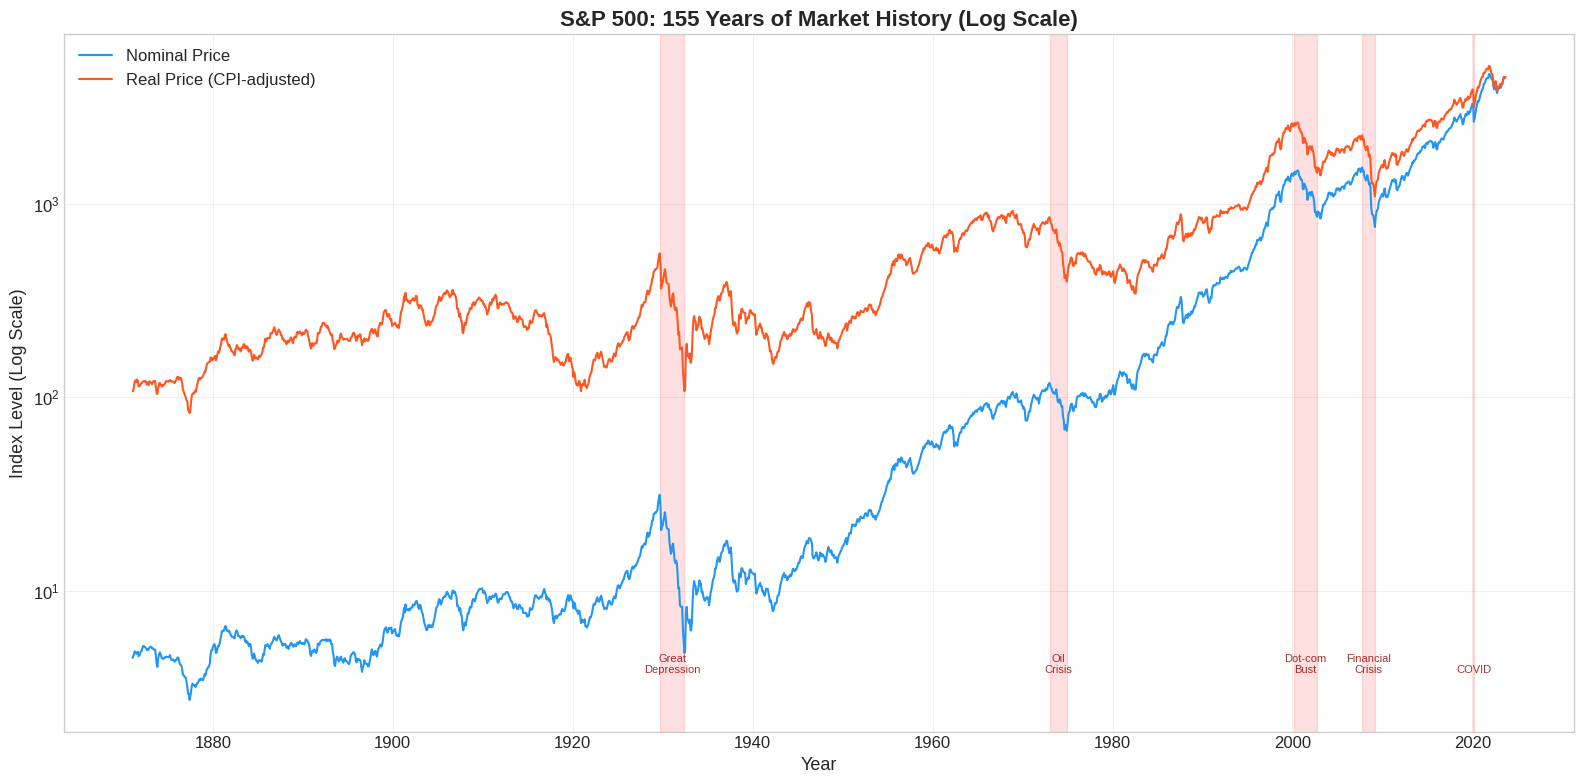


Long-term Compound Annual Growth Rate (CAGR):
  Nominal: 4.63% per year
  Real (after inflation): 2.48% per year
  Inflation drag: 2.15% per year


In [5]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.semilogy(df_clean.index, df_clean['SP500'], linewidth=1.5, label='Nominal Price', color='#2196F3')
ax.semilogy(df_clean.index, df_clean['Real Price'], linewidth=1.5, label='Real Price (CPI-adjusted)', color='#FF5722')

# Shade major crises
crises = [
    ('1929-09-01', '1932-06-01', 'Great\nDepression'),
    ('1973-01-01', '1974-12-01', 'Oil\nCrisis'),
    ('2000-03-01', '2002-10-01', 'Dot-com\nBust'),
    ('2007-10-01', '2009-03-01', 'Financial\nCrisis'),
    ('2020-02-01', '2020-03-01', 'COVID'),
]
for start, end, label in crises:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color='red')
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, ax.get_ylim()[0] * 2, label, ha='center', fontsize=8, color='darkred', alpha=0.8)

ax.set_title('S&P 500: 155 Years of Market History (Log Scale)', fontweight='bold', fontsize=16)
ax.set_xlabel('Year')
ax.set_ylabel('Index Level (Log Scale)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('price_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Compute long-term CAGR
years = (df_clean.index[-1] - df_clean.index[0]).days / 365.25
nominal_cagr = (df_clean['SP500'].iloc[-1] / df_clean['SP500'].iloc[0]) ** (1/years) - 1
real_cagr = (df_clean['Real Price'].iloc[-1] / df_clean['Real Price'].iloc[0]) ** (1/years) - 1
print(f"\nLong-term Compound Annual Growth Rate (CAGR):")
print(f"  Nominal: {nominal_cagr*100:.2f}% per year")
print(f"  Real (after inflation): {real_cagr*100:.2f}% per year")
print(f"  Inflation drag: {(nominal_cagr - real_cagr)*100:.2f}% per year")


## 4. Do Stocks Always Win? Rolling Returns by Holding Period

This is the central analysis of the notebook. We compute rolling real (inflation-adjusted) returns for different holding periods (1, 5, 10, 20, and 30 years) to answer the question: *How long do you need to hold stocks to virtually guarantee a positive real return?*

This analysis uses **price-only** real returns for simplicity. Including dividends would improve the results further.


In [6]:
# Compute rolling annualised real returns for different holding periods
holding_periods = [1, 5, 10, 20, 30]  # in years
rolling_results = {}

for period in holding_periods:
    months = period * 12
    # Annualised return over the period
    rolling_real = (
        (df_clean['Real Price'] / df_clean['Real Price'].shift(months)) ** (1/period) - 1
    ) * 100  # Convert to percentage
    rolling_results[f'{period}Y'] = rolling_real.dropna()

# Summary statistics
print("=== Rolling Annualised Real Returns (%) by Holding Period ===\n")
summary_data = {}
for key, series in rolling_results.items():
    summary_data[key] = {
        'Mean': series.mean(),
        'Median': series.median(),
        'Std Dev': series.std(),
        'Min': series.min(),
        'Max': series.max(),
        '% Positive': (series > 0).mean() * 100,
        'Worst Case': series.min(),
        'N observations': len(series)
    }

rolling_summary = pd.DataFrame(summary_data).round(2)
rolling_summary


=== Rolling Annualised Real Returns (%) by Holding Period ===



,1Y,5Y,10Y,20Y,30Y
Mean,4.09,2.71,2.47,2.16,2.10
Median,4.29,2.52,2.82,2.22,2.07
Std Dev,18.57,7.74,5.10,3.08,2.06
Min,-61.82,-18.44,-10.31,-5.41,-3.52
Max,133.26,27.31,13.73,9.98,6.15
% Positive,59.78,62.13,70.09,75.88,82.40
Worst Case,-61.82,-18.44,-10.31,-5.41,-3.52
N observations,1820.00,1772.00,1712.00,1592.00,1472.00


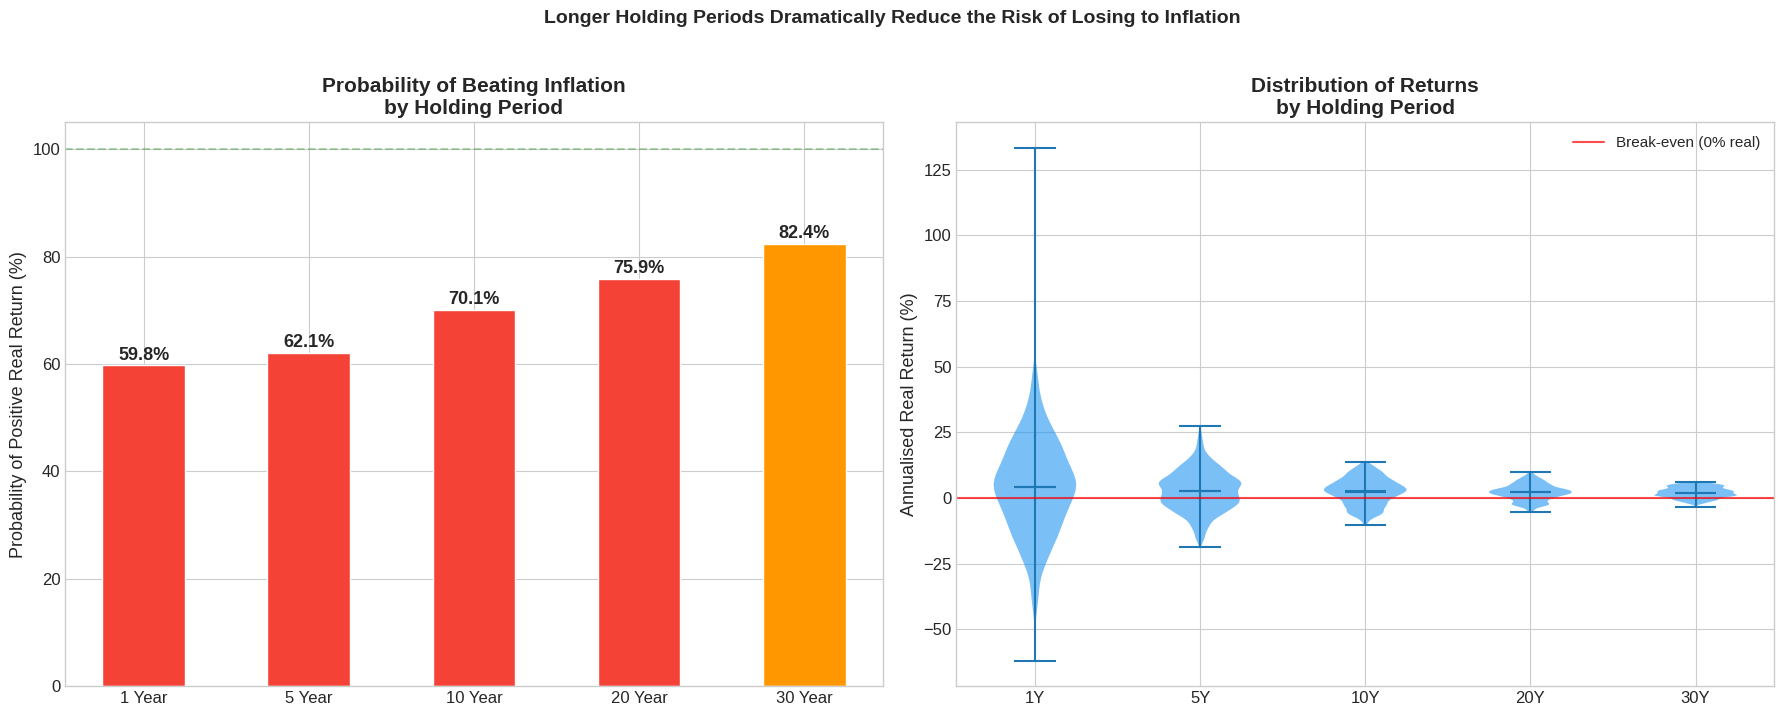

In [7]:
# Visualise: Probability of positive real return by holding period
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: % positive by holding period
pcts = [summary_data[f'{p}Y']['% Positive'] for p in holding_periods]
colours = ['#f44336' if p < 80 else '#ff9800' if p < 95 else '#4caf50' for p in pcts]

bars = axes[0].bar([f'{p} Year' for p in holding_periods], pcts, color=colours,
                    edgecolor='white', width=0.5)
axes[0].set_ylim(0, 105)
axes[0].set_ylabel('Probability of Positive Real Return (%)')
axes[0].set_title('Probability of Beating Inflation\nby Holding Period', fontweight='bold')
axes[0].axhline(y=100, color='green', linestyle='--', alpha=0.3)

for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=13)

# Right: Distribution of returns (violin plot)
violin_data = [rolling_results[f'{p}Y'].values for p in holding_periods]
parts = axes[1].violinplot(violin_data, positions=range(len(holding_periods)),
                           showmeans=True, showmedians=True)

for pc in parts['bodies']:
    pc.set_facecolor('#2196F3')
    pc.set_alpha(0.6)

axes[1].axhline(y=0, color='red', linestyle='-', linewidth=1.5, alpha=0.7, label='Break-even (0% real)')
axes[1].set_xticks(range(len(holding_periods)))
axes[1].set_xticklabels([f'{p}Y' for p in holding_periods])
axes[1].set_ylabel('Annualised Real Return (%)')
axes[1].set_title('Distribution of Returns\nby Holding Period', fontweight='bold')
axes[1].legend(fontsize=11)

plt.suptitle('Longer Holding Periods Dramatically Reduce the Risk of Losing to Inflation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('holding_period_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Starting Valuation Matters: PE10 (CAPE Ratio) Analysis

The Cyclically Adjusted Price-to-Earnings ratio (PE10 or CAPE), developed by Robert Shiller himself, divides the current real price by the 10-year average of real earnings. A high PE10 means stocks are "expensive" relative to their earnings history.

**Key Question:** Does buying when PE10 is high lead to worse subsequent returns?


In [8]:
# Filter data where PE10 is available and meaningful
df_pe = df_clean[df_clean['PE10'] > 0].copy()
print(f"PE10 data available: {df_pe.index[0].strftime('%Y-%m')} to {df_pe.index[-1].strftime('%Y-%m')}")
print(f"PE10 range: {df_pe['PE10'].min():.1f} to {df_pe['PE10'].max():.1f}")

# Compute subsequent 10-year annualised real return for each starting month
months_10y = 120
df_pe['Subsequent_10Y_Real_Return'] = (
    (df_pe['Real Price'].shift(-months_10y) / df_pe['Real Price']) ** (1/10) - 1
) * 100

# Drop rows where we can't compute forward returns
df_pe_valid = df_pe.dropna(subset=['Subsequent_10Y_Real_Return'])

print(f"Valid observations for scatter: {len(df_pe_valid)}")
print(f"\nPE10 descriptive statistics:")
print(df_pe['PE10'].describe().round(1))


PE10 data available: 1881-01 to 2023-09
PE10 range: 4.8 to 44.2
Valid observations for scatter: 1593

PE10 descriptive statistics:
count    1713.0
mean       17.4
std         7.2
min         4.8
25%        12.0
50%        16.5
75%        21.1
max        44.2
Name: PE10, dtype: float64


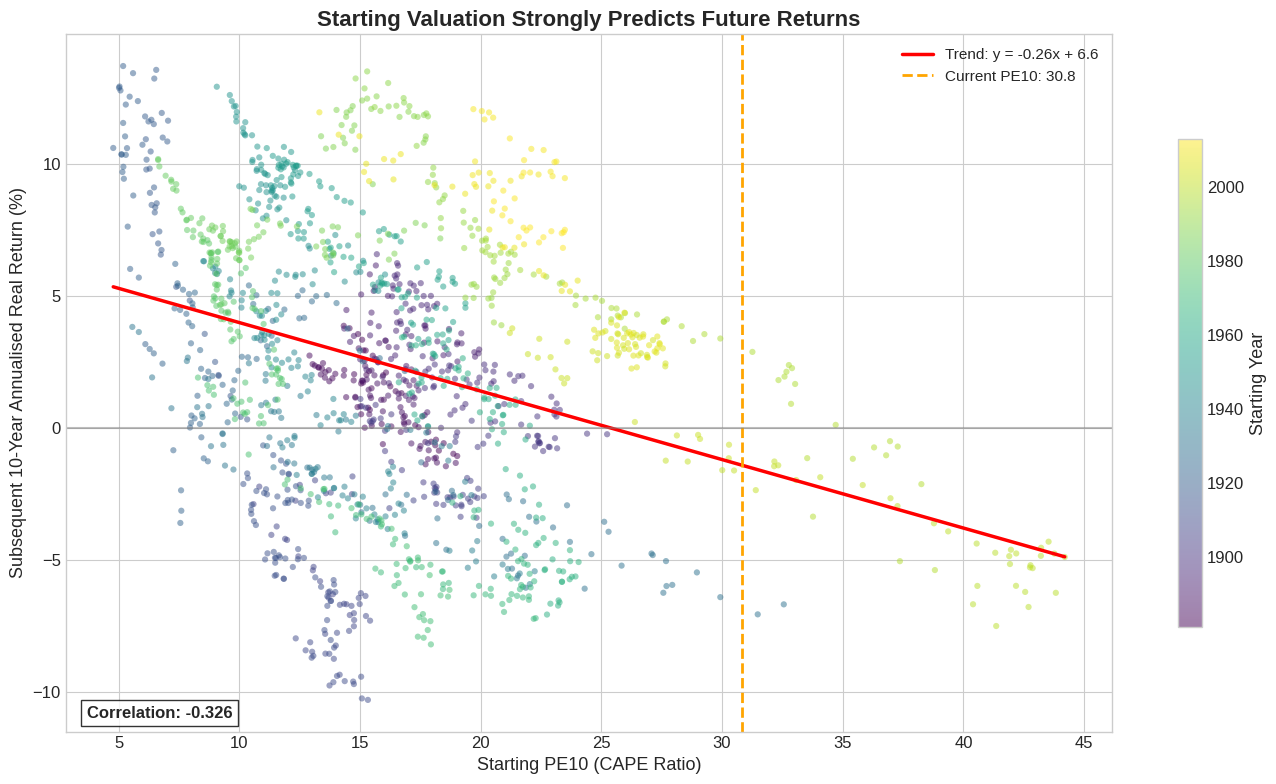


Key finding: The correlation between starting PE10 and subsequent 10-year real return is -0.326.
This strong negative relationship means that buying stocks when they are 'expensive'
(high PE10) historically leads to lower returns over the following decade.


In [9]:
# Scatter plot: PE10 vs subsequent 10-year real return
fig, ax = plt.subplots(figsize=(14, 8))

scatter = ax.scatter(df_pe_valid['PE10'], df_pe_valid['Subsequent_10Y_Real_Return'],
                     c=df_pe_valid.index.year, cmap='viridis', alpha=0.5, s=20, edgecolors='none')

# Add regression line
z = np.polyfit(df_pe_valid['PE10'], df_pe_valid['Subsequent_10Y_Real_Return'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_pe_valid['PE10'].min(), df_pe_valid['PE10'].max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=2.5, label=f'Trend: y = {z[0]:.2f}x + {z[1]:.1f}')

# Correlation
corr = df_pe_valid['PE10'].corr(df_pe_valid['Subsequent_10Y_Real_Return'])
ax.text(0.02, 0.02, f'Correlation: {corr:.3f}', transform=ax.transAxes,
        fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

# Mark current PE10
current_pe10 = df_pe['PE10'].iloc[-1]
if current_pe10 > 0:
    ax.axvline(x=current_pe10, color='orange', linestyle='--', linewidth=2,
               label=f'Current PE10: {current_pe10:.1f}')

ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.set_xlabel('Starting PE10 (CAPE Ratio)')
ax.set_ylabel('Subsequent 10-Year Annualised Real Return (%)')
ax.set_title('Starting Valuation Strongly Predicts Future Returns', fontweight='bold', fontsize=16)
ax.legend(fontsize=11)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('Starting Year')

plt.tight_layout()
plt.savefig('pe10_vs_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey finding: The correlation between starting PE10 and subsequent 10-year real return is {corr:.3f}.")
print("This strong negative relationship means that buying stocks when they are 'expensive'")
print("(high PE10) historically leads to lower returns over the following decade.")


## 6. PE10 Quintile Analysis: Quantifying the Valuation Effect

To make the PE10 insight more actionable, we group all starting months into five quintiles based on PE10 level and compare the distribution of subsequent 10-year returns.


In [10]:
# Create PE10 quintiles
df_pe_valid = df_pe_valid.copy()
df_pe_valid['PE10_Quintile'] = pd.qcut(df_pe_valid['PE10'], q=5, 
                                        labels=['Q1 (Cheap)', 'Q2', 'Q3', 'Q4', 'Q5 (Expensive)'])

# Summary by quintile
quintile_summary = df_pe_valid.groupby('PE10_Quintile', observed=True).agg(
    PE10_Range=('PE10', lambda x: f"{x.min():.1f}–{x.max():.1f}"),
    Mean_Return=('Subsequent_10Y_Real_Return', 'mean'),
    Median_Return=('Subsequent_10Y_Real_Return', 'median'),
    Worst_Return=('Subsequent_10Y_Real_Return', 'min'),
    Best_Return=('Subsequent_10Y_Real_Return', 'max'),
    Pct_Positive=('Subsequent_10Y_Real_Return', lambda x: (x > 0).mean() * 100)
).round(2)

print("=== 10-Year Real Returns by Starting PE10 Quintile ===\n")
quintile_summary


=== 10-Year Real Returns by Starting PE10 Quintile ===



,PE10_Range,Mean_Return,Median_Return,Worst_Return,Best_Return,Pct_Positive
PE10_Quintile,,,,,,
Q1 (Cheap),4.8–11.1,5.51,5.86,-4.98,13.73,91.22
Q2,11.1–14.4,1.96,2.05,-9.76,12.06,60.94
Q3,14.4–17.3,2.08,1.97,-10.31,13.53,72.33
Q4,17.4–21.0,1.77,1.72,-8.20,12.10,63.72
Q5 (Expensive),21.0–44.2,0.24,0.44,-7.51,10.98,51.41


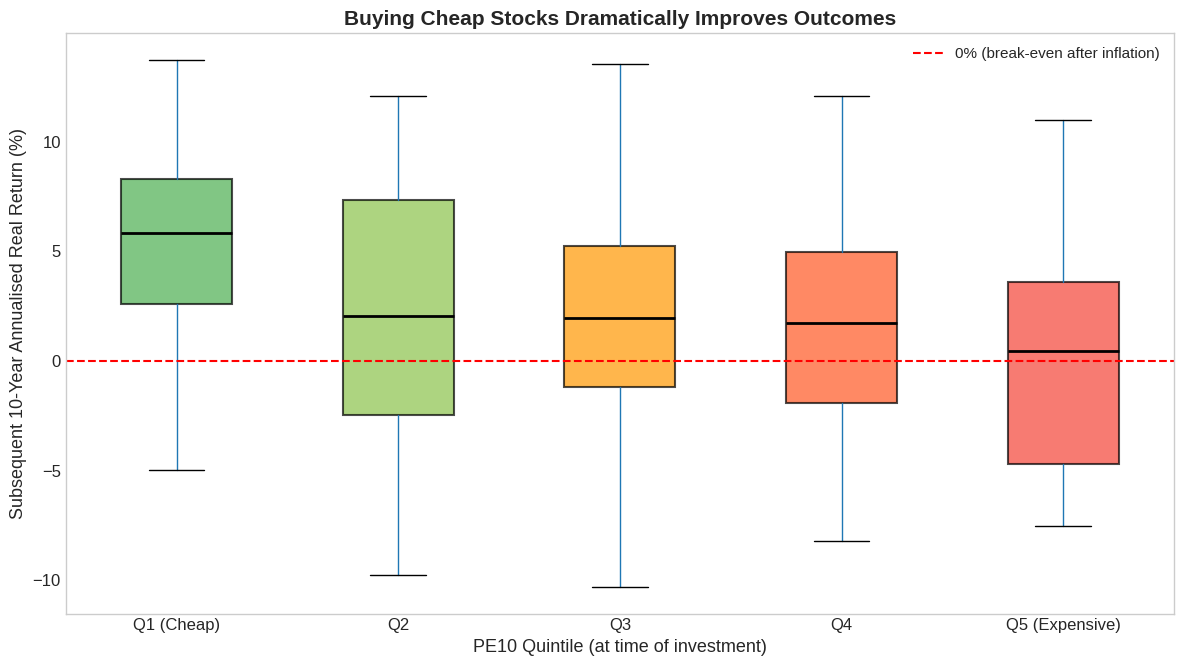


When stocks are cheap (Q1):    Average 10-year real return = 5.5% p.a.
When stocks are expensive (Q5): Average 10-year real return = 0.2% p.a.
Difference: 5.3 percentage points per year!


In [11]:
# Box plot by quintile
fig, ax = plt.subplots(figsize=(12, 7))

colours_q = ['#4caf50', '#8bc34a', '#ff9800', '#ff5722', '#f44336']
bp = df_pe_valid.boxplot(column='Subsequent_10Y_Real_Return', by='PE10_Quintile',
                          ax=ax, grid=False, patch_artist=True,
                          boxprops=dict(linewidth=1.5),
                          medianprops=dict(color='black', linewidth=2),
                          return_type='dict')

for patch, colour in zip(bp['Subsequent_10Y_Real_Return']['boxes'], colours_q):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)

ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='0% (break-even after inflation)')
ax.set_xlabel('PE10 Quintile (at time of investment)')
ax.set_ylabel('Subsequent 10-Year Annualised Real Return (%)')
ax.set_title('Buying Cheap Stocks Dramatically Improves Outcomes', fontweight='bold', fontsize=15)
plt.suptitle('')  # Remove pandas auto-title
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('pe10_quintile_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key insight
cheap_mean = quintile_summary.loc['Q1 (Cheap)', 'Mean_Return']
expensive_mean = quintile_summary.loc['Q5 (Expensive)', 'Mean_Return']
print(f"\nWhen stocks are cheap (Q1):    Average 10-year real return = {cheap_mean:.1f}% p.a.")
print(f"When stocks are expensive (Q5): Average 10-year real return = {expensive_mean:.1f}% p.a.")
print(f"Difference: {cheap_mean - expensive_mean:.1f} percentage points per year!")


## 7. Interest Rates and Inflation Over Time

Interest rates and inflation form the macroeconomic backdrop that influences stock and bond returns. This section provides context for the return analysis above.


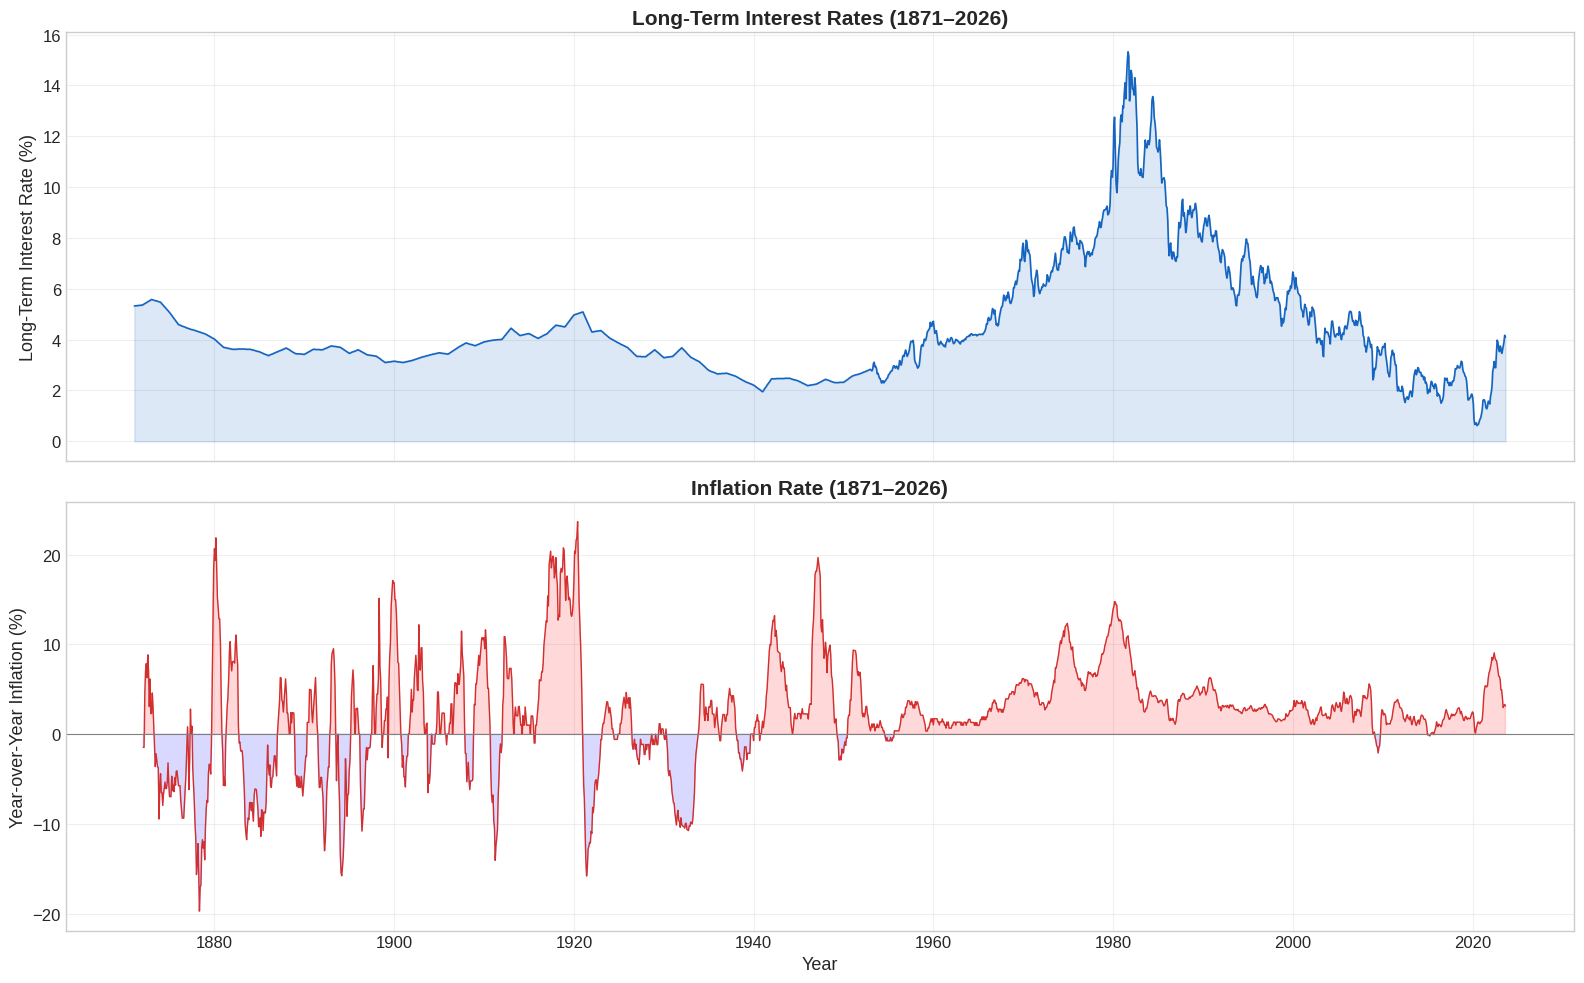

Interest Rate summary:
  Mean: 4.49%
  Current: 4.09%

Inflation summary:
  Mean: 2.29%
  Max: 23.7% (1920-06)


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot 1: Long-term interest rate
axes[0].plot(df_clean.index, df_clean['Long Interest Rate'], linewidth=1.2, color='#1565C0')
axes[0].fill_between(df_clean.index, 0, df_clean['Long Interest Rate'], alpha=0.15, color='#1565C0')
axes[0].set_ylabel('Long-Term Interest Rate (%)')
axes[0].set_title('Long-Term Interest Rates (1871–2026)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Inflation rate (year-over-year CPI change)
df_clean['Inflation_YoY'] = df_clean['Consumer Price Index'].pct_change(12) * 100
axes[1].plot(df_clean.index, df_clean['Inflation_YoY'], linewidth=1, color='#d32f2f')
axes[1].fill_between(df_clean.index, 0, df_clean['Inflation_YoY'],
                      where=df_clean['Inflation_YoY'] > 0, alpha=0.15, color='red')
axes[1].fill_between(df_clean.index, 0, df_clean['Inflation_YoY'],
                      where=df_clean['Inflation_YoY'] <= 0, alpha=0.15, color='blue')
axes[1].axhline(y=0, color='gray', linewidth=0.8)
axes[1].set_ylabel('Year-over-Year Inflation (%)')
axes[1].set_title('Inflation Rate (1871–2026)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rates_and_inflation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("Interest Rate summary:")
print(f"  Mean: {df_clean['Long Interest Rate'].mean():.2f}%")
print(f"  Current: {df_clean['Long Interest Rate'].dropna().iloc[-1]:.2f}%")
print(f"\nInflation summary:")
valid_inflation = df_clean['Inflation_YoY'].dropna()
print(f"  Mean: {valid_inflation.mean():.2f}%")
print(f"  Max: {valid_inflation.max():.1f}% ({valid_inflation.idxmax().strftime('%Y-%m')})")


## 8. Decade-by-Decade Performance

A heatmap of returns by decade reveals long-term cycles. Some decades were exceptional for stocks; others were dismal. This perspective helps investors set realistic expectations.


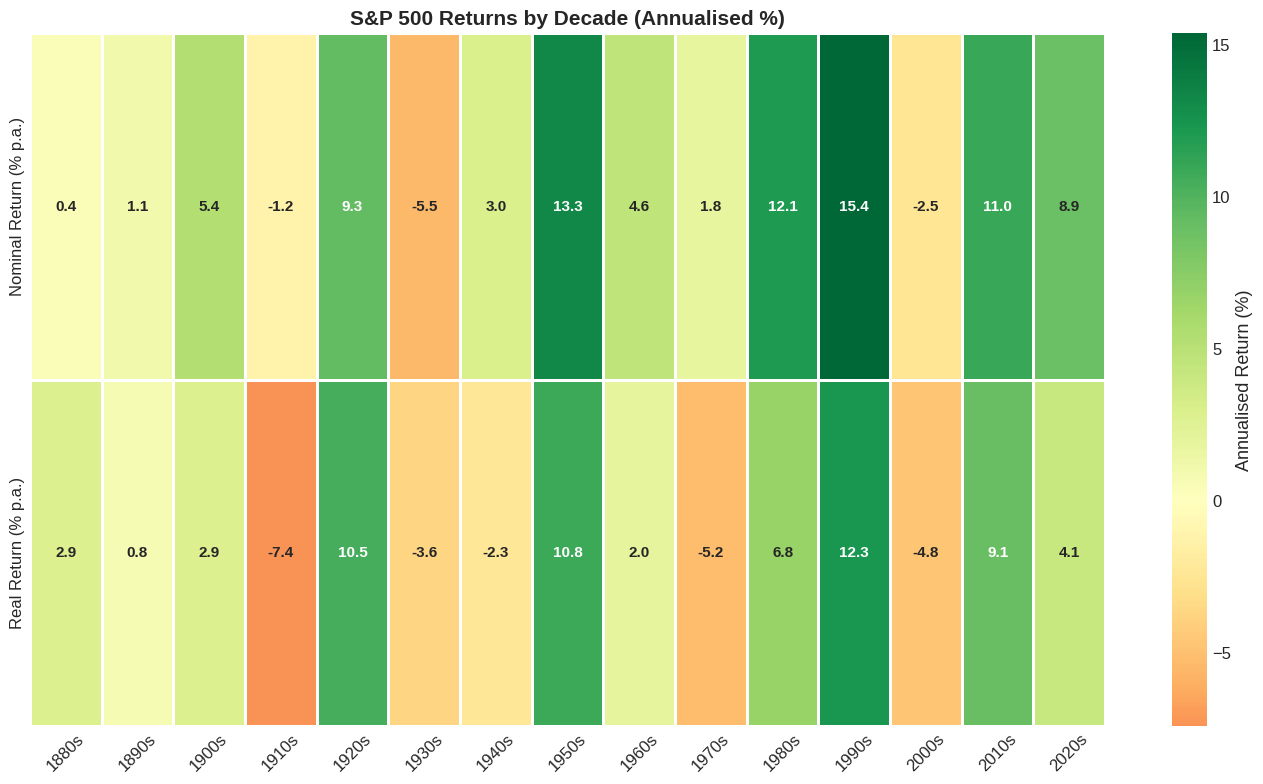


Full decade data:


,Nominal Return (% p.a.),Real Return (% p.a.),Avg PE10,Avg Dividend Yield (%)
1880s,0.4,2.9,15.9,5.0
1890s,1.1,0.8,17.8,4.3
1900s,5.4,2.9,17.7,4.4
1910s,-1.2,-7.4,11.0,5.9
1920s,9.3,10.5,12.2,5.4
1930s,-5.5,-3.6,14.8,5.5
1940s,3.0,-2.3,11.8,5.7
1950s,13.3,10.8,14.6,4.9
1960s,4.6,2.0,20.7,3.2
1970s,1.8,-5.2,12.7,4.0


In [13]:
# Compute decade returns
decades = {}
for year in range(1870, 2030, 10):
    start = f'{year}-01-01'
    end = f'{year+9}-12-31'
    mask = (df_clean.index >= start) & (df_clean.index <= end)
    period_data = df_clean.loc[mask]
    if len(period_data) > 12:  # At least 1 year of data
        nominal_ret = (period_data['SP500'].iloc[-1] / period_data['SP500'].iloc[0]) ** (1/(len(period_data)/12)) - 1
        real_ret = (period_data['Real Price'].iloc[-1] / period_data['Real Price'].iloc[0]) ** (1/(len(period_data)/12)) - 1
        avg_pe10 = period_data[period_data['PE10']>0]['PE10'].mean()
        avg_div = period_data['Dividend_Yield'].mean()
        decades[f"{year}s"] = {
            'Nominal Return (% p.a.)': round(nominal_ret * 100, 1),
            'Real Return (% p.a.)': round(real_ret * 100, 1),
            'Avg PE10': round(avg_pe10, 1) if not np.isnan(avg_pe10) else None,
            'Avg Dividend Yield (%)': round(avg_div * 100, 1) if not np.isnan(avg_div) else None,
        }

decade_df = pd.DataFrame(decades).T
decade_df = decade_df.dropna()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 8))
heatmap_data = decade_df[['Nominal Return (% p.a.)', 'Real Return (% p.a.)']].T

sns.heatmap(heatmap_data.astype(float), annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=1, linecolor='white', ax=ax,
            annot_kws={'size': 11, 'fontweight': 'bold'},
            cbar_kws={'label': 'Annualised Return (%)'})

ax.set_title('S&P 500 Returns by Decade (Annualised %)', fontweight='bold', fontsize=15)
ax.set_ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('decade_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull decade data:")
decade_df


## 9. The Vanishing Dividend: Yield Over Time

Historically, dividends were the primary source of stock returns. Over the past few decades, dividend yields have fallen dramatically as companies shifted to share buybacks. This structural change affects how investors should think about total returns.


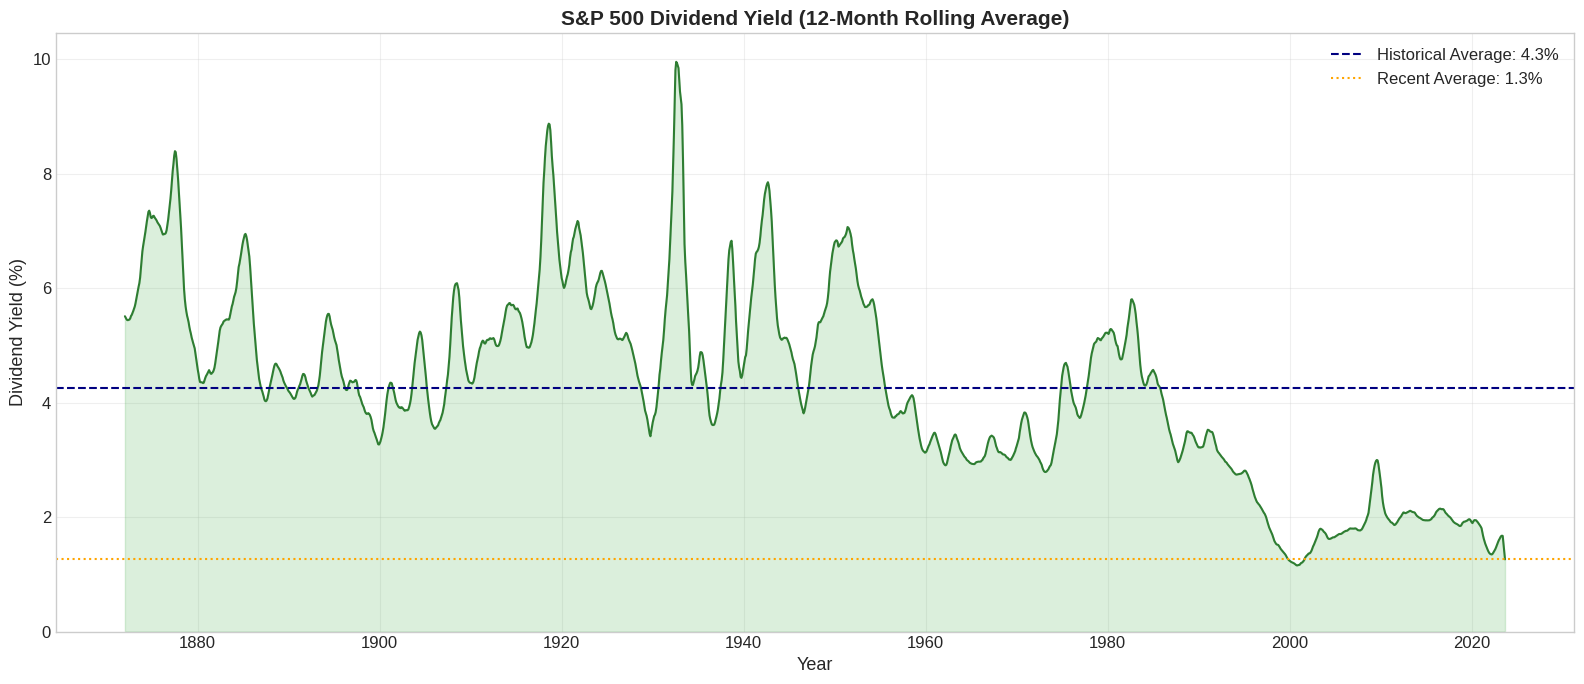

Dividend yield has fallen from a historical average of 4.3%
to approximately 1.3% in recent years.
This means modern investors rely more on capital appreciation than their historical predecessors.


In [14]:
fig, ax = plt.subplots(figsize=(16, 7))

# Compute 12-month rolling average for smoother line
div_yield_pct = df_clean['Dividend_Yield'] * 100
div_yield_smooth = div_yield_pct.rolling(12).mean()

ax.plot(df_clean.index, div_yield_smooth, linewidth=1.5, color='#2e7d32')
ax.fill_between(df_clean.index, 0, div_yield_smooth, alpha=0.2, color='#4caf50')

# Historical average
avg_yield = div_yield_pct.mean()
ax.axhline(y=avg_yield, color='navy', linestyle='--', linewidth=1.5,
           label=f'Historical Average: {avg_yield:.1f}%')

# Recent
recent_yield = div_yield_pct.iloc[-12:].mean()
ax.axhline(y=recent_yield, color='orange', linestyle=':', linewidth=1.5,
           label=f'Recent Average: {recent_yield:.1f}%')

ax.set_xlabel('Year')
ax.set_ylabel('Dividend Yield (%)')
ax.set_title('S&P 500 Dividend Yield (12-Month Rolling Average)', fontweight='bold', fontsize=15)
ax.legend(fontsize=12)
ax.set_ylim(0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dividend_yield.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Dividend yield has fallen from a historical average of {avg_yield:.1f}%")
print(f"to approximately {recent_yield:.1f}% in recent years.")
print("This means modern investors rely more on capital appreciation than their historical predecessors.")


## 10. Key Insights and Actionable Findings

### Finding 1: Time is the Investor's Greatest Ally
Over 1-year periods, stocks fail to beat inflation roughly 30–35% of the time. But over 20-year periods, this failure rate drops dramatically. The lesson: long-term investors should not panic during short-term market drops.

### Finding 2: Starting Valuation is the Strongest Predictor of Future Returns
The PE10 (CAPE ratio) shows a strong negative correlation with subsequent 10-year returns. Buying when stocks are cheap (low PE10) historically produces substantially better outcomes. This is arguably the most important chart in the notebook.

### Finding 3: Inflation is the Silent Killer of Returns
The gap between nominal and real returns amounts to 2–3% per year over the full history. Over decades, this compounds into an enormous difference. Investors who ignore inflation overestimate their real wealth gains significantly.

### Finding 4: No Decade is "Typical"
Decade-by-decade returns range from deeply negative (1930s) to extraordinarily positive (1990s). The long-term average of ~7% real return is a *mean* — individual decades can deviate widely.

### Finding 5: Dividends Used to Matter More
Historical dividend yields of 4–6% have compressed to under 2%. Modern investors are more reliant on capital gains, which are inherently more volatile than dividend income.

### Practical Recommendation
For the target retail investor, this analysis supports three evidence-based strategies:
1. **Invest for the long term** (10+ years minimum) to maximise the probability of positive real returns
2. **Pay attention to valuations** — be cautious (but not absent) when PE10 is extremely high
3. **Always think in real terms** — nominal returns overstate true wealth creation


## 11. Final Product: Investment Horizon Scorecard

This is the deliverable — a clear, user-friendly scorecard that summarises the probability of positive real returns for different holding periods and valuation environments.


In [15]:
# Build the final scorecard
print("=" * 76)
print("  INVESTMENT HORIZON SCORECARD".center(76))
print("  Based on 155 Years of S&P 500 Data (Shiller Dataset)".center(76))
print("=" * 76)
print()

# Part 1: By holding period
print("Part 1: Probability of Beating Inflation by Holding Period")
print("-" * 60)
print(f"{'Holding Period':<20} {'Prob. Positive Real Return':>28} {'Worst Case':>12}")
print("-" * 60)
for period in holding_periods:
    key = f'{period}Y'
    prob = summary_data[key]['% Positive']
    worst = summary_data[key]['Worst Case']
    flag = '⚠' if prob < 90 else '✓'
    print(f"  {period:>2} year(s) {flag}       {prob:>24.1f}%    {worst:>8.1f}%")
print()

# Part 2: By starting PE10
print("Part 2: 10-Year Outlook by Starting Valuation (PE10)")
print("-" * 60)
for idx, row in quintile_summary.iterrows():
    print(f"  {idx:<18} PE10 {row['PE10_Range']:>12}  →  Avg return: {row['Mean_Return']:>5.1f}% p.a.")
print()

# Current context
current_pe = df_pe['PE10'].iloc[-1]
if current_pe > 0:
    print(f"Current PE10: {current_pe:.1f}")
    if current_pe > df_pe['PE10'].quantile(0.8):
        print("→ Current valuation is in the top 20% historically (expensive).")
        print("  Historical precedent suggests below-average 10-year returns from this level.")
    elif current_pe < df_pe['PE10'].quantile(0.2):
        print("→ Current valuation is in the bottom 20% historically (cheap).")
        print("  Historical precedent suggests above-average 10-year returns from this level.")
    else:
        print("→ Current valuation is in the middle range historically.")

print()
print("=" * 76)
print("  Disclaimer: Past performance does not guarantee future results.".center(76))
print("  This analysis is for educational purposes only.".center(76))
print("=" * 76)


                         INVESTMENT HORIZON SCORECARD                       
             Based on 155 Years of S&P 500 Data (Shiller Dataset)           

Part 1: Probability of Beating Inflation by Holding Period
------------------------------------------------------------
Holding Period         Prob. Positive Real Return   Worst Case
------------------------------------------------------------
   1 year(s) ⚠                           59.8%       -61.8%
   5 year(s) ⚠                           62.1%       -18.4%
  10 year(s) ⚠                           70.1%       -10.3%
  20 year(s) ⚠                           75.9%        -5.4%
  30 year(s) ⚠                           82.4%        -3.5%

Part 2: 10-Year Outlook by Starting Valuation (PE10)
------------------------------------------------------------
  Q1 (Cheap)         PE10     4.8–11.1  →  Avg return:   5.5% p.a.
  Q2                 PE10    11.1–14.4  →  Avg return:   2.0% p.a.
  Q3                 PE10    14.4–17.3  →  Avg retur

## 12. Technical Notes

### Methods Used

| Step | Method | Library |
|------|--------|---------|
| Data Acquisition | `git clone` from [github.com/datasets/s-and-p-500](https://github.com/datasets/s-and-p-500) | subprocess |
| Data Cleaning | Remove zero/NaN rows, compute derived metrics | pandas |
| Return Calculation | Monthly percentage change (price-only and CPI-adjusted) | pandas |
| Rolling Analysis | Rolling annualised real returns for 1–30 year holding periods | pandas, NumPy |
| Valuation Analysis | PE10 quintile grouping, correlation with forward returns, OLS regression | pandas, NumPy |
| Inflation Analysis | Year-over-year CPI change | pandas |
| Visualisation | Line charts, scatter plots, heatmaps, violin plots, box plots | Matplotlib, Seaborn |

### Limitations

1. **Price-only real returns**: The rolling return analysis uses price-only real returns (excluding reinvested dividends). Including dividends would improve the probability of positive outcomes further.
2. **Survivorship bias**: The S&P 500 index itself has survivorship bias — poorly performing companies are removed and replaced. Individual stock investors may not achieve index-level returns.
3. **US-centric**: All data is for the US market. Other countries have experienced prolonged periods of negative real returns (e.g., Japan since 1989).
4. **PE10 limitations**: The PE10 ratio uses 10-year average earnings, which may not reflect current business conditions. Structural changes (e.g., the shift from manufacturing to technology) may affect its predictive power.
5. **No transaction costs or taxes**: Real-world investors face brokerage fees and capital gains taxes that reduce net returns.
6. **Non-stationarity**: Economic regimes change over 155 years. The relationships observed in the 19th century may not hold in the 21st century.

### Reproducibility
- Data: `git clone https://github.com/datasets/s-and-p-500.git`
- Seed: Not applicable (no randomisation)
- Python 3.10+, pandas, numpy, matplotlib, seaborn
- All charts saved as PNG files in the working directory


---

### AI Disclosure

The following AI tools were used in the preparation of this assignment:

| Tool | Model/Version | Date | Usage |
|------|--------------|------|-------|
| Claude | Claude (Anthropic) | April 2026 | Assisted with notebook structure, code drafting, chart formatting, and markdown writing. All analytical decisions, interpretations, dataset selection, and the final product design were made by the author. |

---
*Notebook created for ACC102 Mini Assignment (Track 2).*  
*Data: Robert Shiller's S&P 500 Dataset, accessed from [github.com/datasets/s-and-p-500](https://github.com/datasets/s-and-p-500) (PDDL license), April 2026.*
